# Data Driven : Machine Learning Project

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df=pd.read_csv('Amazon.csv')
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   643 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

## Task 1: Data Cleaning and Preparation

#### Remove duplicate or inconsistent survey responses.

In [93]:
df.duplicated().sum()

np.int64(0)

#### Standardize categorical entries.

In [94]:
categorical_col = df.select_dtypes(include='object').columns
for i in categorical_col:
    df[i]=df[i].str.strip()

In [95]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


#### Handle missing values and inconsistent formats in Product_Search_Method and other fields.

In [96]:
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     157
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

Replacing null values of column with mode of column values as the column is categorical.

In [97]:
df['Product_Search_Method']=df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0])

In [98]:
df.isnull().sum()

Timestamp                                 0
age                                       0
Gender                                    0
Purchase_Frequency                        0
Purchase_Categories                       0
Personalized_Recommendation_Frequency     0
Browsing_Frequency                        0
Product_Search_Method                     0
Search_Result_Exploration                 0
Customer_Reviews_Importance               0
Add_to_Cart_Browsing                      0
Cart_Completion_Frequency                 0
Cart_Abandonment_Factors                  0
Saveforlater_Frequency                    0
Review_Left                               0
Review_Reliability                        0
Review_Helpfulness                        0
Personalized_Recommendation_Frequency     0
Recommendation_Helpfulness                0
Rating_Accuracy                           0
Shopping_Satisfaction                     0
Service_Appreciation                      0
Improvement_Areas               

#### Rename duplicate or misformatted columns.

In [99]:
df.rename(columns={df.columns[17]:'Personalized_Recommendation_Frequency_1'},inplace=True)
df.columns=df.columns.str.strip()

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Timestamp                                800 non-null    object
 1   age                                      800 non-null    int64 
 2   Gender                                   800 non-null    object
 3   Purchase_Frequency                       800 non-null    object
 4   Purchase_Categories                      800 non-null    object
 5   Personalized_Recommendation_Frequency    800 non-null    object
 6   Browsing_Frequency                       800 non-null    object
 7   Product_Search_Method                    800 non-null    object
 8   Search_Result_Exploration                800 non-null    object
 9   Customer_Reviews_Importance              800 non-null    int64 
 10  Add_to_Cart_Browsing                     800 non-null    objec

#### Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis.

In [101]:
col=['age','Customer_Reviews_Importance','Personalized_Recommendation_Frequency_1','Rating_Accuracy','Shopping_Satisfaction','transaction']
for e in col:
    df[e]=pd.to_numeric(df[e])

In [102]:
df[e].dtypes

dtype('int64')

## Task 2: Descriptive Behavior Analysis

#### Summarize customer demographics (age, gender distribution).

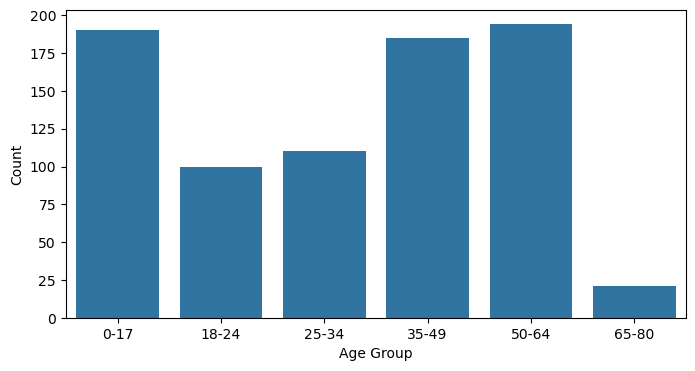

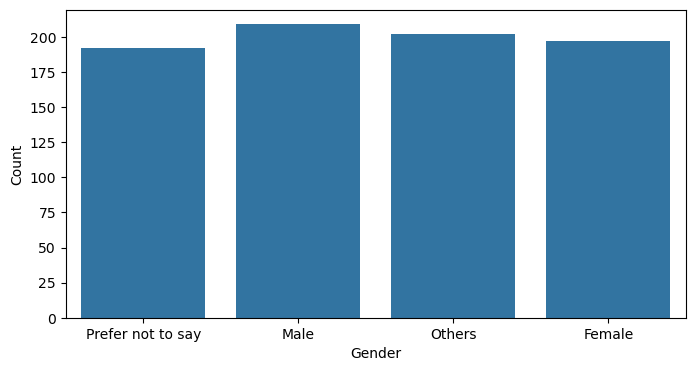

In [103]:
age_bins=[0,18,25,35,50,65,80]
age_labels=['0-17','18-24','25-34','35-49','50-64','65-80']
df['age_group']=pd.cut(df['age'],bins=age_bins,labels=age_labels)
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='age_group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

 #### Analyze overall purchase frequency and most popular product categories.

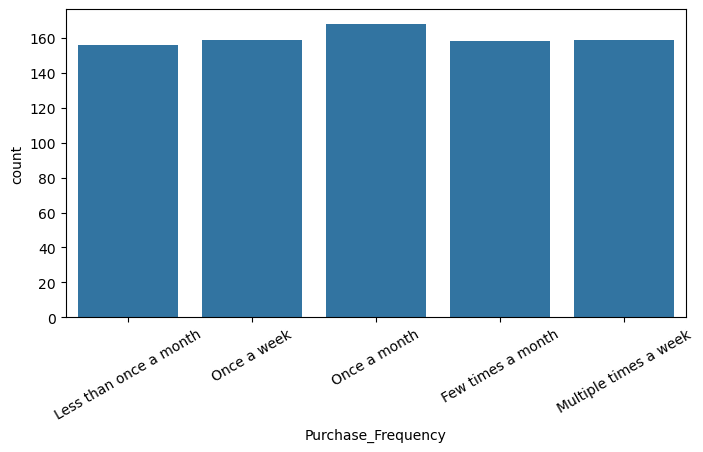

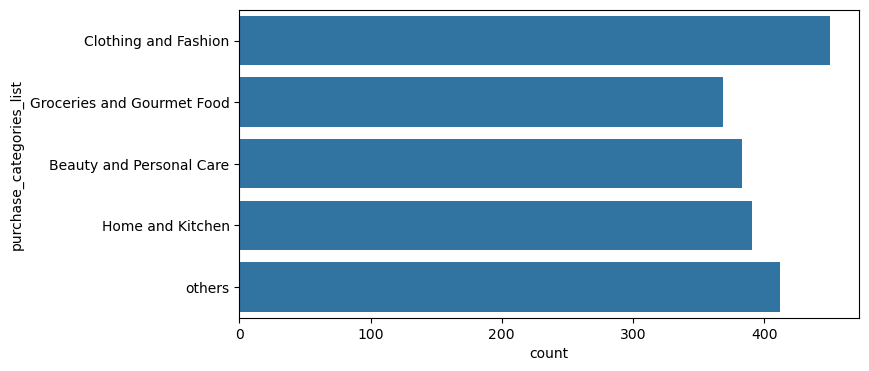

In [104]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Purchase_Frequency')
plt.xticks(rotation=30)
plt.show()

df['purchase_categories_list']=df['Purchase_Categories'].str.split(';')
pc=df.explode('purchase_categories_list')
plt.figure(figsize=(8,4))
sns.countplot(data=pc,y='purchase_categories_list')
plt.show()

#### Identify top browsing methods and most common cart abandonment factors.

In [105]:
browsing_method=df.groupby('Product_Search_Method').agg(freq=('Product_Search_Method','count')).reset_index()
browsing_method                                                       

,Product_Search_Method,freq
0,Filter,161
1,Keyword,327
2,categories,163
3,others,149


Top Browsing Method is 'KEYWORD'

In [106]:
factor=df.groupby('Cart_Abandonment_Factors').agg(freq=('Cart_Abandonment_Factors','count')).reset_index()
factor

,Cart_Abandonment_Factors,freq
0,Changed my mind or no longer need the item,194
1,Found a better price elsewhere,206
2,High shipping costs,224
3,others,176


Most Common Cart Abandonment Factor is 'High Shipping Cost'

#### Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

In [107]:
print(df['Shopping_Satisfaction'].mean())
print(df['Shopping_Satisfaction'].median())

3.0125
3.0


In [108]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Recommendation_Helpfulness']=lb.fit_transform(df['Recommendation_Helpfulness'])
print(df['Recommendation_Helpfulness'].mean())
print(df['Recommendation_Helpfulness'].median())

1.01
1.0


In [109]:
print(df['Rating_Accuracy'].mean())
print(df['Rating_Accuracy'].median())

2.96875
3.0


#### Generate summary statistics and visualizations for key behavioral variables.

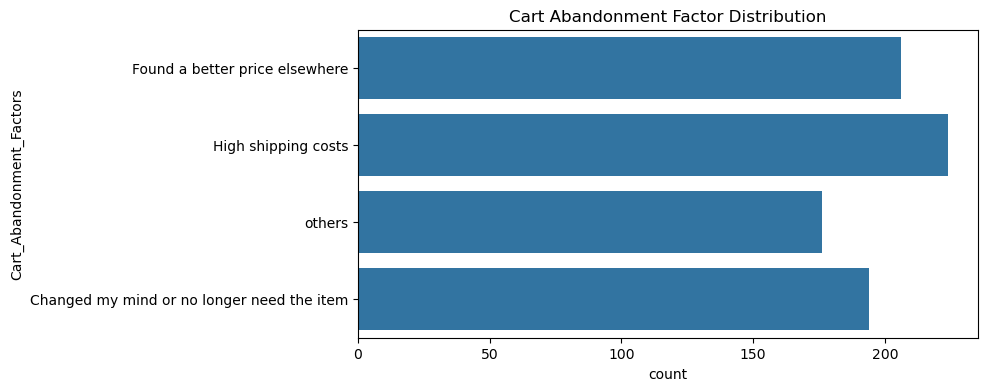

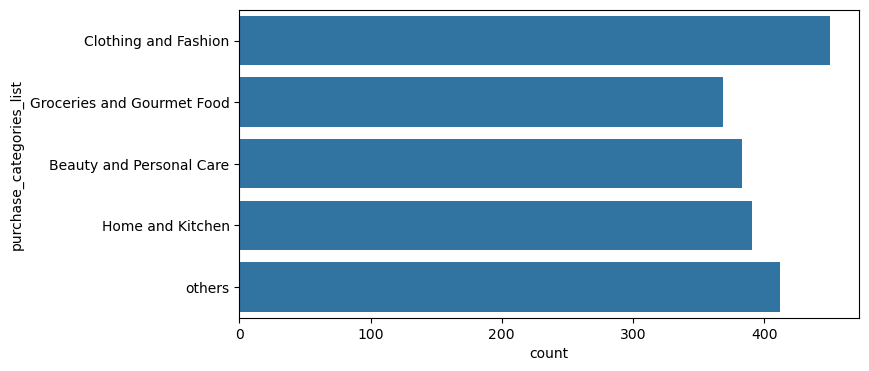

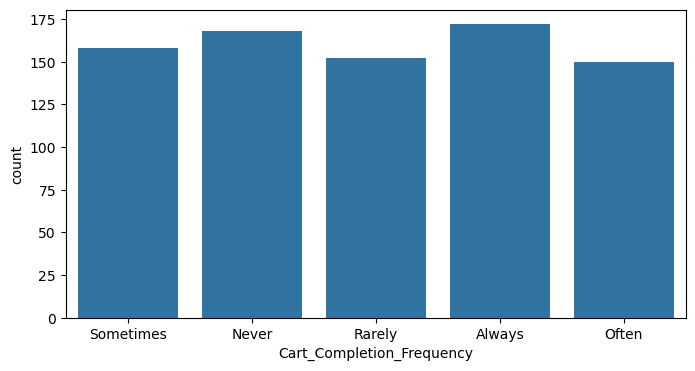

In [119]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,y='Cart_Abandonment_Factors')
plt.title('Cart Abandonment Factor Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=pc,y='purchase_categories_list')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Cart_Completion_Frequency')
plt.show()             

- Most customer do not buy product after adding it to cart due to hogh shipping cost.

- Mostly customer like to buy cloth and fashion products.

- Mostly customers buy products after adding it to cart.

## Task 3: Customer Segmentation and Profiling

#### Segment customers based on purchase frequency and shopping satisfaction levels.

In [117]:
df['purchase_frq_level']=df['Purchase_Frequency'].apply(lambda x:'low' if x in ['Less than once a month','Once a month'] else 'medium'
                                                if x in ['Few times a month','Once a week'] else 'high')
df['satisfaction_level']=df['Shopping_Satisfaction'].apply(lambda x: 'low' if x<2 else 'medium' if x<4 else 'high')
customer_seg=df.groupby(['purchase_frq_level','satisfaction_level']).size().reset_index(name='customer_count')
customer_seg

,purchase_frq_level,satisfaction_level,customer_count
0,high,high,75
1,high,low,19
2,high,medium,65
3,low,high,135
4,low,low,60
5,low,medium,129
6,medium,high,110
7,medium,low,73
8,medium,medium,134


#### Create profiles for - 

Frequent Buyers : High purchase frequency, high satisfaction.

Occasional Shoppers : Medium frequency, moderate satisfaction.

At-Risk Customers : Low satisfaction or frequent cart abandonment.

In [21]:
Cust_Profile=df.apply(lambda x:'Frequent Buyers' if x['purchase_frq_level']=='high' and x['satisfaction_level']=='high' else 'Occassional Shoppers' 
                 if x['purchase_frq_level']=='medium' and x['satisfaction_level']=='medium' else 'At Risk Customers' 
                 if (x['satisfaction_level']=='low') or (x['Cart_Completion_Frequency']=='Never') else 'other', axis=1)
Cust_Profile.value_counts().reset_index()

,index,count
0,other,355
1,At Risk Customers,236
2,Occassional Shoppers,134
3,Frequent Buyers,75


#### Analyze demographic or behavioral differences across these segments.

Demographic differences across these segments.

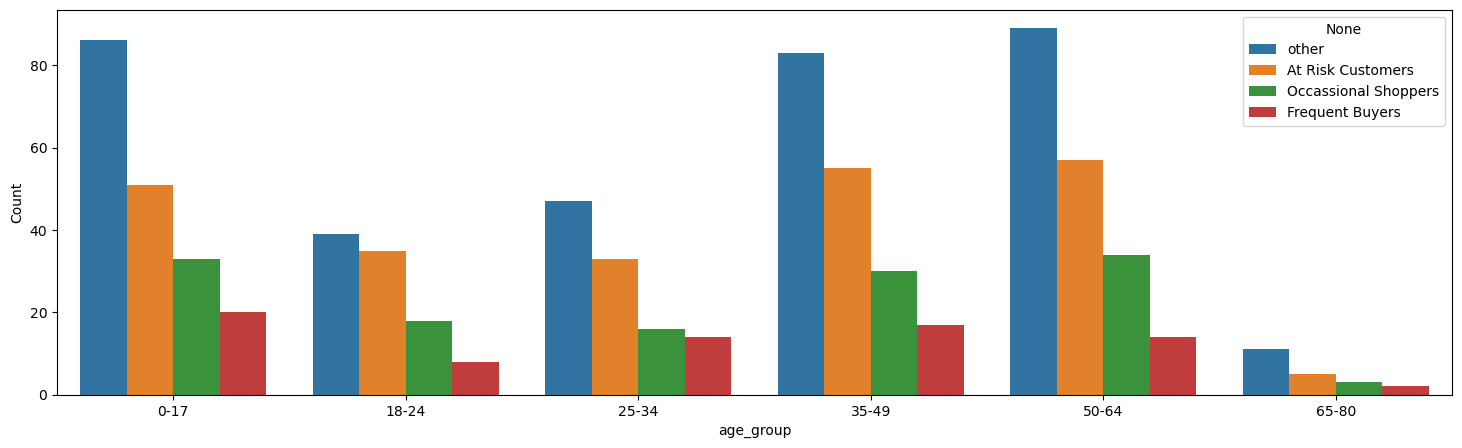

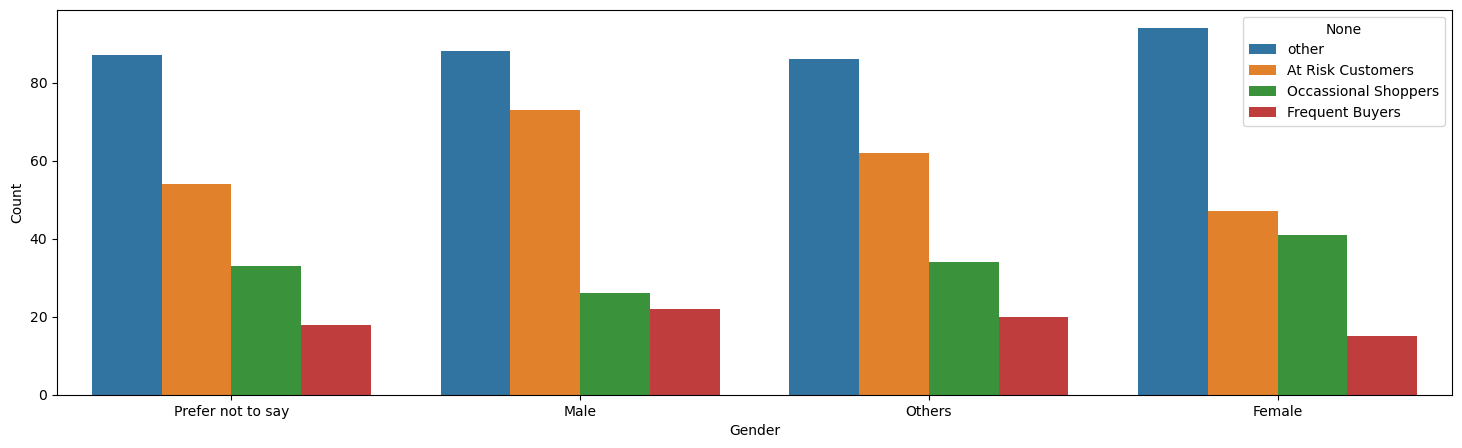

In [22]:
plt.figure(figsize=(18,5))
sns.countplot(data=df,x='age_group',hue=Cust_Profile)
plt.xlabel('age_group')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(18,5))
sns.countplot(data=df,x='Gender',hue=Cust_Profile)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

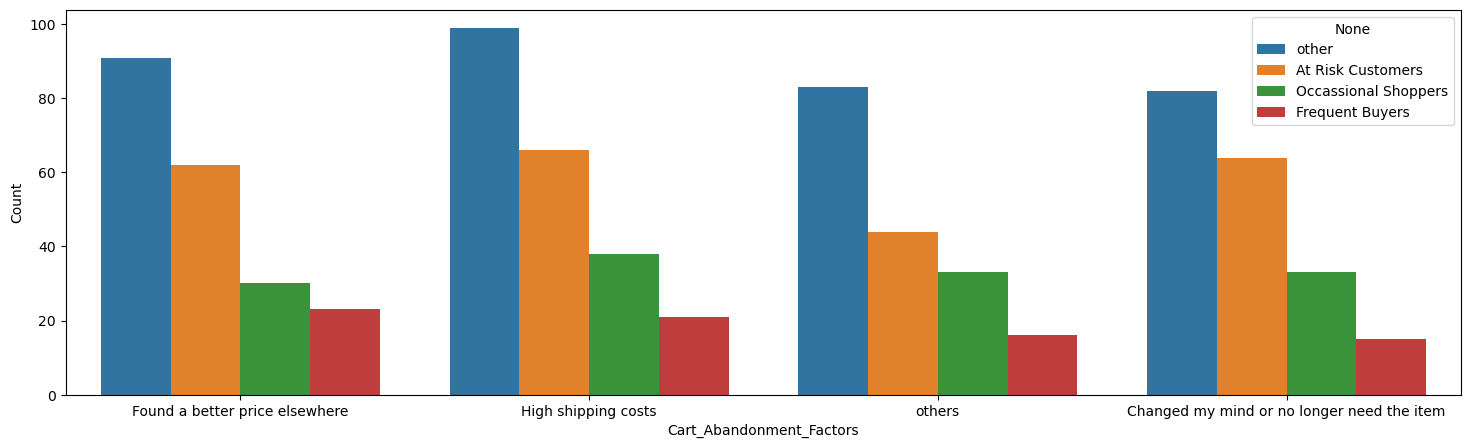

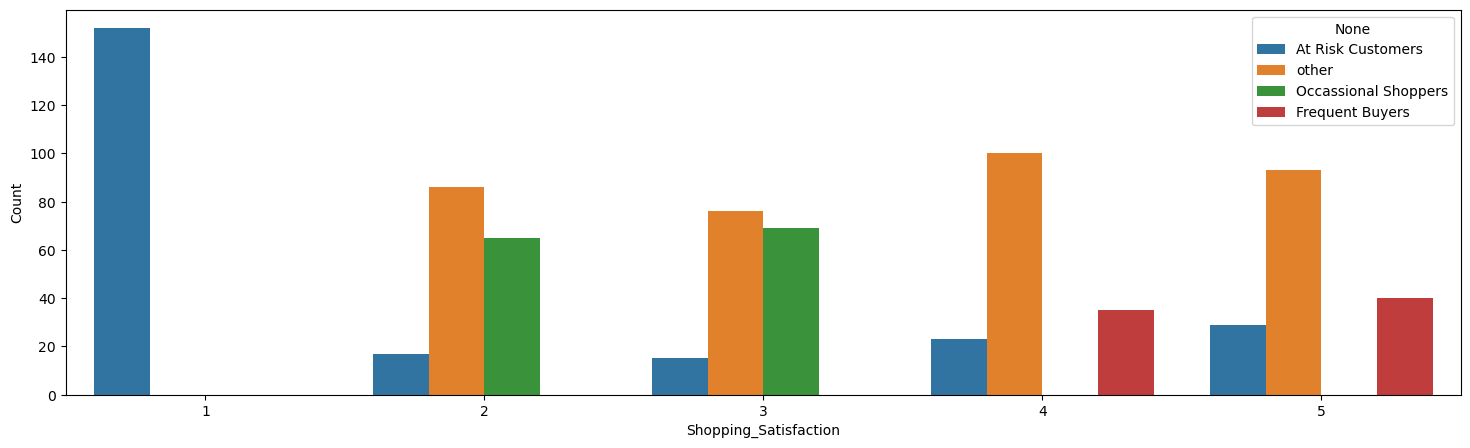

In [23]:
plt.figure(figsize=(18,5))
sns.countplot(data=df,x='Cart_Abandonment_Factors',hue=Cust_Profile)
plt.xlabel('Cart_Abandonment_Factors')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(18,5))
sns.countplot(data=df,x='Shopping_Satisfaction',hue=Cust_Profile)
plt.xlabel('Shopping_Satisfaction')
plt.ylabel('Count')
plt.show()

#### Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.

In [24]:
x=df.iloc[:,[9,20]]
x.head()

,Customer_Reviews_Importance,Shopping_Satisfaction
0,2,4
1,3,5
2,2,3
3,2,2
4,5,2


In [25]:
x.shape

(800, 2)

In [26]:
x.isnull().sum()

Customer_Reviews_Importance    0
Shopping_Satisfaction          0
dtype: int64

WCSS
 [3166.1137499999995, 1992.6336137820515, 1260.0014653596372, 766.3314137730875, 669.7860965872537, 564.1675837762582, 578.5564552674662, 412.7793738182848, 343.18362379473047]


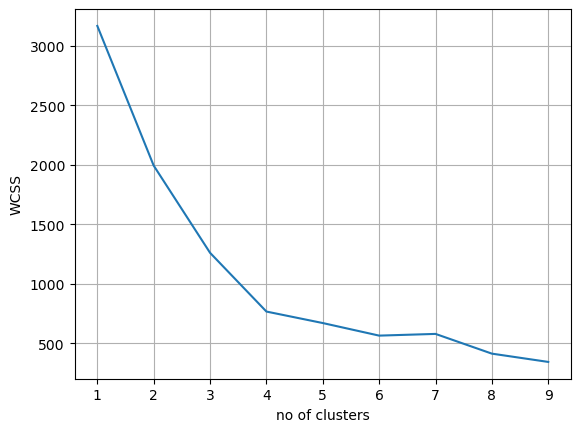

In [27]:
## WCSS - within cluster sum of square
from sklearn.cluster import KMeans
WCSS=[]
for i in range(1,10):
    m=KMeans(n_clusters=i)
    m.fit(x)
    WCSS.append(m.inertia_)
    
## Elbow Plot   
print('WCSS\n', WCSS)
plt.plot (list(range(1,10)),WCSS)
plt.xlabel('no of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

#### Acc. to Elbow Plot optimal number of clusters = 4

In [28]:
K4 = KMeans(n_clusters=4)
K4.fit(x)
ypred4 = K4.predict(x)
print(ypred4)

[0 1 0 3 2 0 1 2 3 1 1 1 1 2 2 3 3 3 2 2 3 0 1 2 3 3 0 1 1 1 3 1 2 0 3 1 0
 3 3 1 1 1 0 1 1 1 0 1 3 0 1 0 2 2 1 1 0 2 0 0 1 0 0 0 0 1 1 0 1 2 0 1 3 2
 2 3 3 0 2 1 1 2 1 0 0 1 3 3 0 3 1 2 2 0 2 3 3 3 2 0 2 2 0 1 3 3 3 2 3 0 3
 1 0 1 3 1 1 1 1 2 0 2 0 1 1 1 0 3 0 1 1 1 1 1 2 1 0 2 0 1 3 1 3 3 2 0 0 0
 0 0 0 1 3 2 1 1 3 1 0 3 2 0 2 2 3 1 0 1 1 1 1 0 0 1 2 0 1 3 1 0 3 0 2 3 1
 3 1 1 1 0 2 0 2 3 3 3 1 2 2 1 3 0 3 3 0 1 0 1 3 1 1 1 1 1 1 0 2 0 3 3 0 2
 0 2 3 2 0 1 3 0 1 1 2 3 3 0 3 0 1 3 1 0 1 3 3 0 1 0 1 2 2 1 0 2 3 1 1 0 2
 2 0 0 1 0 0 3 0 1 0 0 0 0 0 1 2 1 1 0 2 1 0 0 3 1 3 2 0 1 1 1 0 0 1 1 1 1
 3 1 0 1 0 3 0 3 3 1 3 0 3 2 0 0 1 2 1 2 1 1 2 3 0 1 0 3 2 1 3 0 2 1 2 1 3
 3 2 0 1 3 3 0 2 0 3 0 3 3 1 2 2 3 1 3 1 1 1 2 1 0 1 3 0 1 0 1 3 0 0 3 1 0
 2 3 0 1 0 2 1 0 3 3 2 1 0 2 3 0 2 3 3 0 3 1 1 0 3 0 0 3 1 1 2 0 1 0 2 0 3
 2 2 0 0 3 3 3 1 3 1 0 1 2 1 0 3 1 3 1 2 0 0 0 1 2 3 0 0 3 2 0 1 3 3 2 0 1
 0 2 2 0 2 0 2 2 1 1 3 3 2 1 1 2 0 3 2 0 1 1 1 3 3 3 3 0 3 0 1 1 3 0 3 0 0
 2 0 1 3 3 2 0 3 1 1 0 3 

## Task 4: Recommendation and Review Insights

#### Examine the relationship between recommendation helpfulness and shopping satisfaction.

<Axes: >

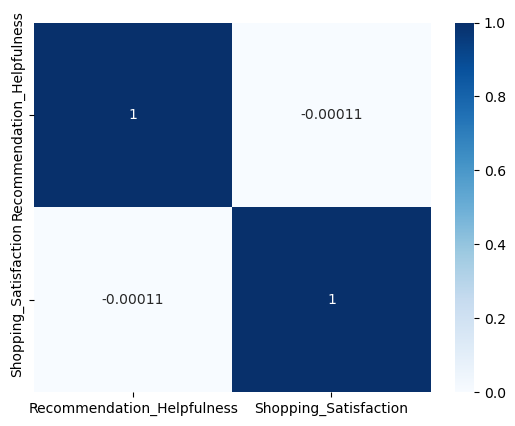

In [29]:
## As we converted 'Recommendation_Helpfulness'  datatype to numerical using LabelEncoder earlier.
sns.heatmap(df[['Recommendation_Helpfulness','Shopping_Satisfaction']].corr(),annot=True,cmap='Blues')

 As there is -0.00011 correlation between 'Recommendation_Helpfulness' and 'Shopping_Satisfaction' which colser to zero.
it means if one factor increases the other will decrease slightly. There is no relationship between them.

#### Evaluate how review reliability and helpfulness impact overall ratings.

<Axes: >

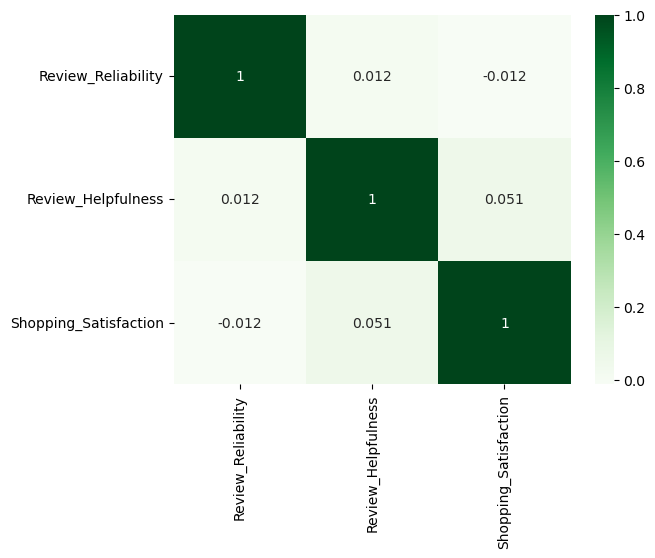

In [30]:
df['Review_Helpfulness']=lb.fit_transform(df['Review_Helpfulness'])   ## use labelencoder to convert datatype to numerical.
df['Review_Reliability']=lb.fit_transform(df['Review_Reliability'])
sns.heatmap(df[['Review_Reliability','Review_Helpfulness','Shopping_Satisfaction']].corr(),annot=True,cmap='Greens')

As we can see in heatmap there is slightly negative impact of 'Review_Reliabilty" on overall rating (shopping_satisfaction).

'Review_Helpfulness' has positive impact on overall rating, means customers who have find review helpful give a good overall ratings.

####  Identify trends in how often customers engage with or trust personalized recommendations.

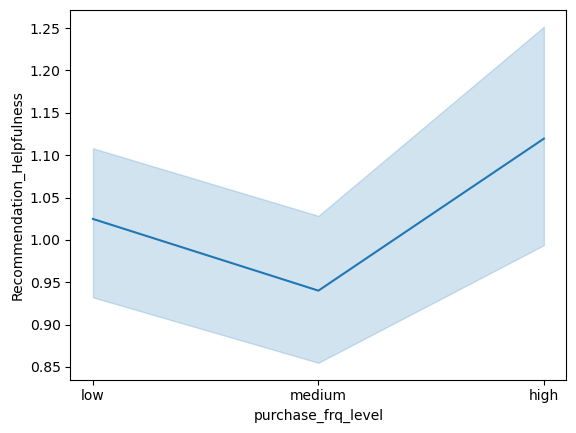

In [31]:
sns.lineplot(data=df,x='purchase_frq_level',y='Recommendation_Helpfulness')
plt.show()

As we can clearly see from the trend that customers who found recommendation helpful are engaging frequently.

That means most customer trust the recommendations.

#### Suggest actionable insights for improving Amazon’s recommendation system.

- As the common cart abandonment factor is 'High shipping cost' so, recommend mostly the products which have low shipping cost.
- Low shopping satisfaction can be related with poor recommendation so, review the past interactions to find factor for dissatisfaction and recomment product with high customer rating.
- Customers often like to move to similar categories so, recommend more cross-related product categories.
- Most customer like cloth and fashion products so recommend trending cloth and fashion products.

## Task 5: Visualization and Reporting 

#### Create attractive visualizations for :

#### 1. Purchase Categories

In [32]:
df['purchase_categories_list']=df['Purchase_Categories'].str.split(';')
pc=df.explode('purchase_categories_list')

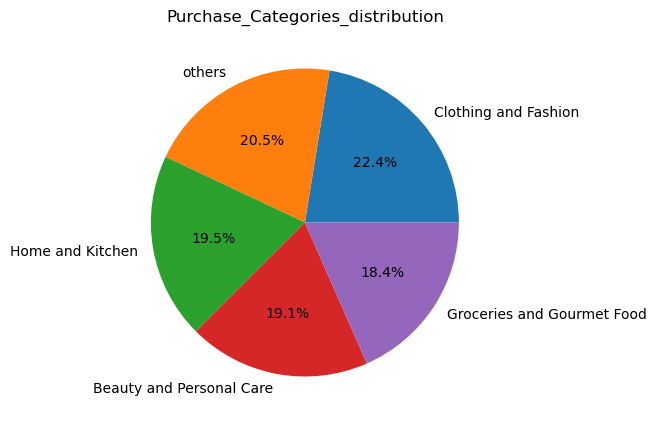

In [33]:
cat_counts=pc['purchase_categories_list'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cat_counts.values,labels=cat_counts.index,autopct='%1.1f%%')
plt.title('Purchase_Categories_distribution')
plt.show()

#### 2. Browsing frequency distribution

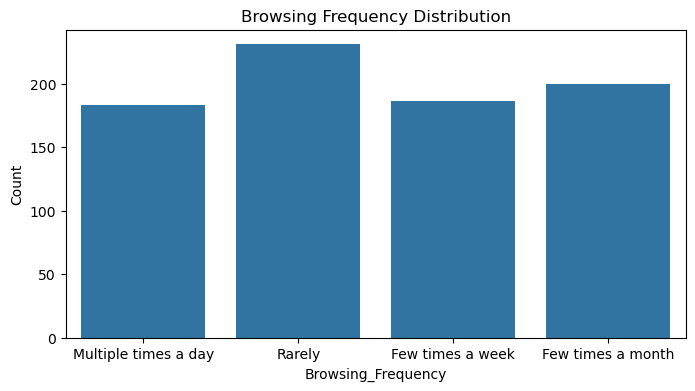

In [34]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Browsing_Frequency')
plt.xlabel('Browsing_Frequency')
plt.ylabel('Count')
plt.title('Browsing Frequency Distribution')
plt.show()

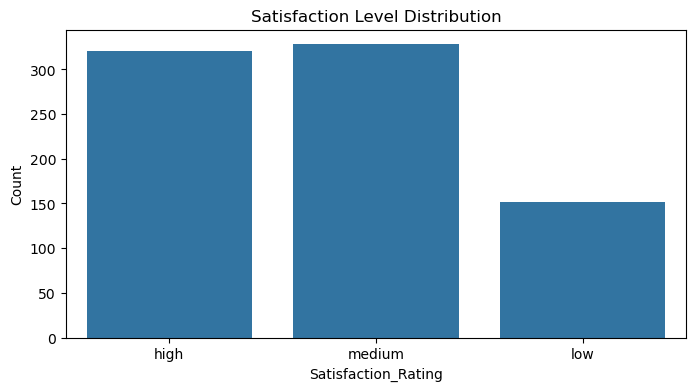

In [35]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='satisfaction_level')
plt.xlabel('Satisfaction_Rating')
plt.ylabel('Count')
plt.title('Satisfaction Level Distribution')
plt.show()

#### 3. Correlation between recommendation usefulness and satisfaction

<Axes: >

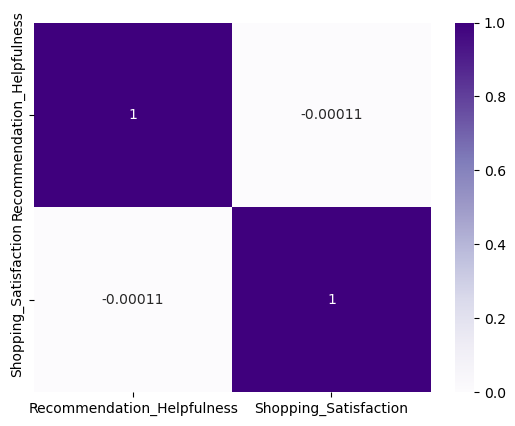

In [36]:
sns.heatmap(df[['Recommendation_Helpfulness','Shopping_Satisfaction']].corr(),annot=True,cmap='Purples')

#### Summarize findings in a clear and visually appealing dashboard or report format.

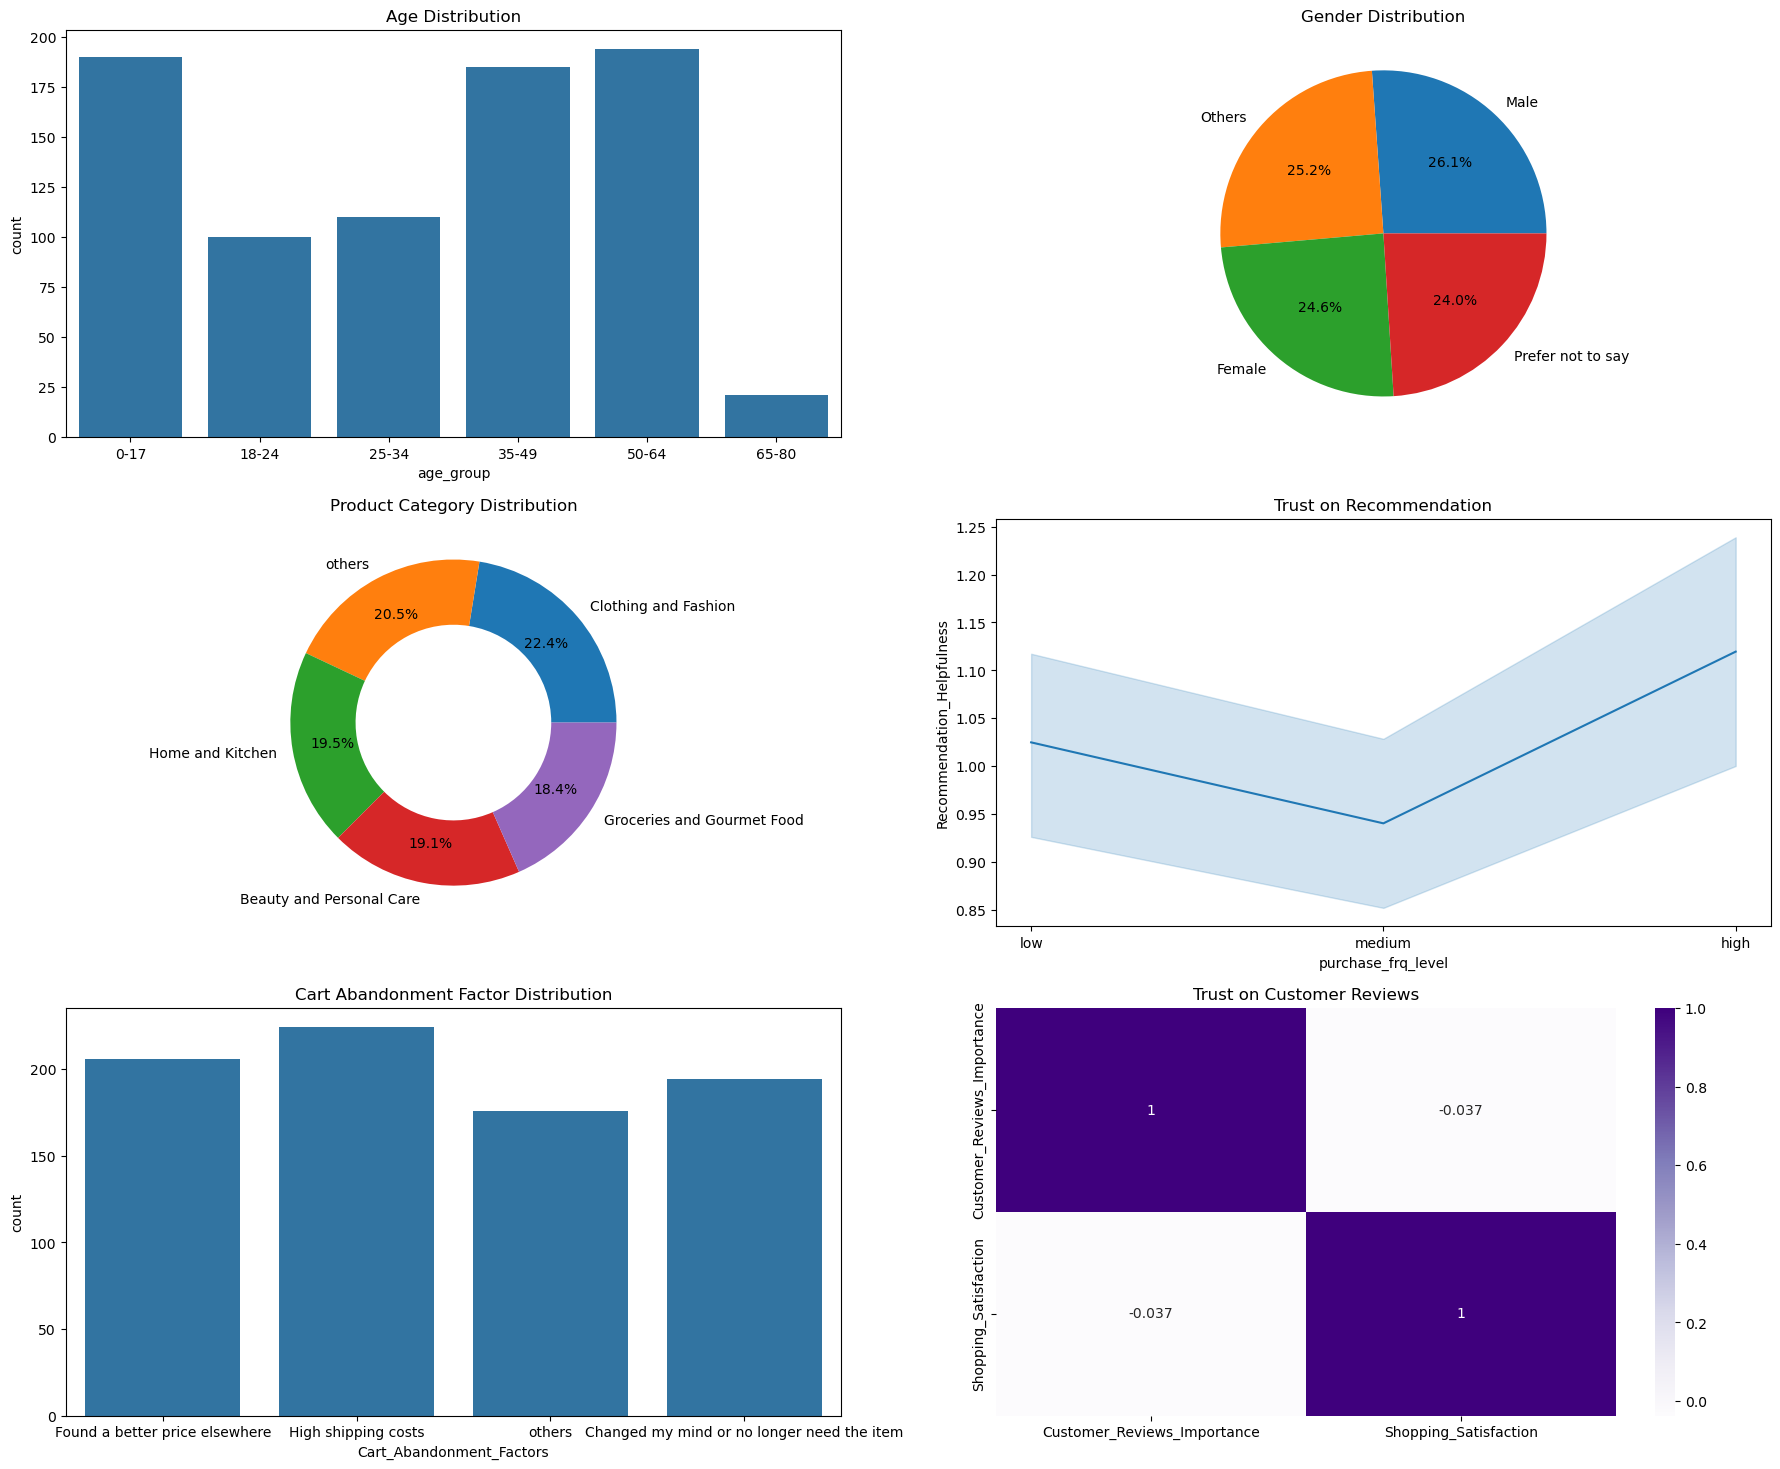

In [51]:
plt.figure(figsize=(22,18))

plt.subplot(3,2,1)
sns.countplot(data=df,x='age_group')
plt.title('Age Distribution')

plt.subplot(3,2,2)
gender=df['Gender'].value_counts()
plt.pie(gender.values,labels=gender.index,autopct='%1.1f%%')
plt.title('Gender Distribution')

plt.subplot(3,2,3)
plt.pie(cat_counts.values,labels=cat_counts.index,autopct='%1.1f%%',pctdistance=0.75,wedgeprops={'width':0.4})
plt.title('Product Category Distribution')

plt.subplot(3,2,4)
sns.lineplot(data=df,x='purchase_frq_level',y='Recommendation_Helpfulness')
plt.title('Trust on Recommendation')

plt.subplot(3,2,5)
sns.countplot(data=df,x='Cart_Abandonment_Factors')
plt.title('Cart Abandonment Factor Distribution')

plt.subplot(3,2,6)
sns.heatmap(df[['Customer_Reviews_Importance','Shopping_Satisfaction']].corr(),annot=True,cmap='Purples')
plt.title('Trust on Customer Reviews')

plt.show()